# State of Data Brasil — Análise de Gênero (2021–2024)

> **Objetivo:** Investigar desigualdades de gênero no mercado de dados brasileiro.  
> **Recorte:** Gênero × Remuneração, Faixa Salarial e Senioridade.  
> **Split ML:** Treino = 2021–2023 (com features de IA de 2023) · Teste = 2024 (com features de IA de 2024)


---
## Seção 0 — Imports e Carregamento da base de dados

In [98]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from xgboost import XGBClassifier
import shap

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

SEED  = 42
np.random.seed(SEED)
ALPHA = 0.05
print('OK')

OK


In [39]:
dfs_raw = {
    '2021': pd.read_csv('data/state_of_data_2021.csv', low_memory=False),
    '2022': pd.read_csv('data/state_of_data_2022.csv', low_memory=False),
    '2023': pd.read_csv('data/state_of_data_2023.csv', low_memory=False),
    '2024': pd.read_csv('data/state_of_data_2024.csv', low_memory=False),
}
for ano, df_raw in dfs_raw.items():
    print(f'{ano}: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')

2021: 2,645 linhas × 356 colunas
2022: 4,271 linhas × 353 colunas
2023: 5,293 linhas × 399 colunas
2024: 5,217 linhas × 403 colunas


### 0.1 Mapeamento de colunas por ano

In [40]:
COLUMN_MAPPING = {
    '2021': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_a ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_e ', 'Estado onde mora')",
        'uf':               "('P1_e_a ', 'uf onde mora')",
        'regiao':           "('P1_e_b ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_g_b ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_h ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_i ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_q ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2022': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_p ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2023': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_r ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2024': {
        'idade':            '1.a_idade',
        'faixa_idade':      '1.a.1_faixa_idade',
        'genero':           '1.b_genero',
        'estado':           '1.i_estado_onde_mora',
        'uf':               '1.i.1_uf_onde_mora',
        'regiao':           '1.i.2_regiao_onde_mora',
        'regiao_origem':    '1.k.2_regiao_de_origem',
        'nivel_ensino':     '1.l_nivel_de_ensino',
        'area_formacao':    '1.m_área_de_formação',
        'situacao':         '2.a_situação_de_trabalho',
        'setor':            '2.b_setor',
        'cargo':            '2.f_cargo_atual',
        'gestor':           '2.d_atua_como_gestor',
        'nivel':            '2.g_nivel',
        'faixa_salarial':   '2.h_faixa_salarial',
        'tempo_area_dados': '2.i_tempo_de_experiencia_em_dados',
        'tempo_area_ti':    '2.j_tempo_de_experiencia_em_ti',
        'modalidade':       '2.r_modelo_de_trabalho_atual',
    }
}

IA_COLS = {
    '2023': {
        'ia_prioridade_empresa':      "('P3_e ', 'AI Generativa é uma prioridade em sua empresa?')",
        'ia_tipos_uso_gestao':        "('P3_f ', 'Tipos de uso de AI Generativa e LLMs na empresa')",
        'ia_motivos_nao_usar':        "('P3_g ', 'Motivos que levam a empresa a não usar AI Genrativa e LLMs')",
        'ia_tipo_uso_pessoal':        "('P4_l ', 'Qual o tipo de uso de AI Generativa e LLMs na empresa')",
        'ia_usa_chatgpt_no_trabalho': "('P4_m ', 'Utiliza ChatGPT ou LLMs no trabalho?')",
    },
    '2024': {
        'ia_prioridade_empresa':      '3.e_ai_generativa_e_llm_é_uma_prioridade?',
        'ia_tipos_uso_gestao':        '3.f_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_motivos_nao_usar':        '3.g_motivos_para_não_usar_ai_generativa_e_llm',
        'ia_tipo_uso_pessoal':        '4.l_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_usa_chatgpt_no_trabalho': '4.m_usa_chatgpt_ou_copilot_no_trabalho?',
    },
}

IA_FEATS_ALL = [
    'ia_prioridade_empresa',
    'ia_tipos_uso_gestao',
    'ia_motivos_nao_usar',
    'ia_tipo_uso_pessoal',
    'ia_usa_chatgpt_no_trabalho'
]

### 0.2 Mapeamentos ordinais e de categorias

In [41]:
FAIXA_SALARIAL_MAP = {
    'de R$ 1.001/mês a R$ 2.000/mês':   'R$1k-2k',
    'de R$ 2.001/mês a R$ 3.000/mês':   'R$2k-3k',
    'de R$ 2.001/mês a R$ 3000/mês':    'R$2k-3k',
    'de R$ 3.001/mês a R$ 4.000/mês':   'R$3k-4k',
    'de R$ 4.001/mês a R$ 6.000/mês':   'R$4k-6k',
    'de R$ 6.001/mês a R$ 8.000/mês':   'R$6k-8k',
    'de R$ 8.001/mês a R$ 12.000/mês':  'R$8k-12k',
    'de R$ 12.001/mês a R$ 16.000/mês': 'R$12k-16k',
    'de R$ 16.001/mês a R$ 20.000/mês': 'R$16k-20k',
    'de R$ 20.001/mês a R$ 25.000/mês': 'R$20k-25k',
    'de R$ 25.001/mês a R$ 30.000/mês': 'R$25k-30k',
    'de R$ 30.001/mês a R$ 40.000/mês': 'R$30k-40k',
    'Acima de R$ 40.001/mês':           'R$40k+',
}
FAIXA_SALARIAL_ORDEM = [
    'R$1k-2k', 'R$2k-3k', 'R$3k-4k', 'R$4k-6k', 'R$6k-8k',
    'R$8k-12k', 'R$12k-16k', 'R$16k-20k', 'R$20k-25k',
    'R$25k-30k', 'R$30k-40k', 'R$40k+',
]
NIVEL_ENSINO_ORDEM = [
    'Não tenho graduação formal', 'Estudante de Graduação',
    'Graduação/Bacharelado', 'Especialização Lato Sensu',
    'Mestrado', 'Doutorado ou Phd',
]
#NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior', 'Gestor']
NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior']  # leakage
NIVEL_SENIORIDADE_EDA    = ['Júnior', 'Pleno', 'Sênior', 'Gestor']  # EDA

CARGO_MAP = {
    'Analista de Dados/Data Analyst':                    'Analista de Dados',
    'Analista de BI/BI Analyst':                         'Analista de Dados',
    'Analista de BI/BI Analyst/Analytics Engineer':      'Analista de Dados',
    'Analista de Negócios/Business Analyst':             'Analista de Dados',
    'Analista de Inteligência de Mercado/Market Intelligence': 'Analista de Dados',
    'Analista de Marketing':                             'Analista de Dados',
    'Analista Administrativo':                           'Analista de Dados',
    'Estatístico':                                       'Analista de Dados',
    'Economista':                                        'Analista de Dados',
    'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer':                 'Engenheiro de Dados',
    'Analytics Engineer':                                'Engenheiro de Dados',
    'Arquiteto de Dados':                                'Engenheiro de Dados',
    'Arquiteto de dados':                                'Engenheiro de Dados',
    'DBA/Administrador de Banco de Dados':               'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':  'Engenheiro de Dados',
    'Arquiteto de Dados/Data Architect':                 'Engenheiro de Dados',
    'Cientista de Dados/Data Scientist':                 'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer':        'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Cientista de Dados',
    'Professor':                                         'Professor/Pesquisador',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Product Manager/ Product Owner (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Desenvolvedor',
    'Desenvolvedor ou Engenheiro de Software':           'Desenvolvedor',
    'Analista de Sistemas/Analista de TI':               'Desenvolvedor',
    'Analista de Suporte/Analista Técnico':              'Desenvolvedor',
    'Suporte Técnico':                                   'Desenvolvedor',
    'Técnico':                                           'Desenvolvedor',
    'Outra Opção':                                       'Outro',
    'Outras Engenharias (não inclui dev)':               'Outro',
}
AREA_FORMACAO_MAP = {
    'Computação / Engenharia de Software / Sistemas de Informação/ TI': 'Computação / TI',
    'Outras Engenharias': 'Engenharia (outras)',
    'Outras Engenharias (não incluir engenharia de software ou TI)': 'Engenharia (outras)',
    'Economia/ Administração / Contabilidade / Finanças/ Negócios': 'Economia / Adm / Finanças',
    'Economia/ Administração / Contabilidade / Finanças': 'Economia / Adm / Finanças',
    'Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais': 'Estatística / Matemática',
    'Estatística/ Matemática / Matemática Computacional': 'Estatística / Matemática',
    'Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde': 'Ciências da Saúde',
    'Ciências Biológicas/Farmácia/Medicina/Área da Saúde': 'Ciências da Saúde',
    'Marketing / Publicidade / Comunicação / Jornalismo': 'Marketing / Comunicação',
    'Marketing / Publicidade / Comunicação / Jornalismo / Ciências Sociais': 'Marketing / Comunicação',
    'Outra opção': 'Outras',
}
SITUACAO_MAP = {
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil':      'Remoto p/ exterior',
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil (PJ)': 'Remoto p/ exterior',
    'Desempregado, buscando recolocação':                                   'Desempregado',
    'Desempregado e não estou buscando recolocação':                        'Desempregado',
    'Somente Estudante (graduação)':                                        'Somente Estudante',
    'Somente Estudante (pós-graduação)':                                    'Somente Estudante',
    'Prefiro não informar':                                                  None,
}

REGIAO_MAP = {
    'Centro_Oeste': 'Centro-Oeste', 'Centro Oeste': 'Centro-Oeste',
    'centro-oeste': 'Centro-Oeste', 'Centro-oeste': 'Centro-Oeste',
    'nordeste': 'Nordeste', 'norte': 'Norte',
    'sudeste': 'Sudeste',  'sul':    'Sul',
    'Exterior': None, 'Prefiro não informar': None,
}

ANOS     = ['2021', '2022', '2023', '2024']
REGIOES = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']

CORES_GENERO = {'Masculino': '#517493', 'Feminino': '#64313E'}
CORES_REGIAO = {
    'Sudeste':      '#2563EB',
    'Sul':          '#16A34A',
    'Nordeste':     '#EA580C',
    'Centro-Oeste': '#9333EA',
    'Norte':        '#CA8A04',
}
TEMPLATE = 'plotly_white'

---
## Seção 1 — Pipeline de pré-processamento

In [42]:
def build_year_dataframe(df_raw: pd.DataFrame, year: str) -> pd.DataFrame:

    # COLUNAS BASE
    
    base_map = COLUMN_MAPPING[year]

    cols_base = {
        old: new
        for new, old in base_map.items()
        if old in df_raw.columns
    }

    df = df_raw[list(cols_base.keys())].rename(columns=cols_base).copy()

    
    # COLUNAS DE IA (2023/2024)
    
    if year in IA_COLS:

        ia_map = IA_COLS[year]

        cols_ia = {
            old: new
            for new, old in ia_map.items()
            if old in df_raw.columns
        }
        
        ia_df = (df_raw[list(cols_ia.keys())].rename(columns=cols_ia))

        df = pd.concat([df, ia_df], axis=1)

    # ANO
   
    df.insert(0, 'ano_pesquisa', year)

    return df
    

In [43]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:

    
    # GÊNERO
    
    df = df[df['genero'].isin(['Masculino', 'Feminino'])].copy()

    # NÍVEL DE ENSINO
    
    df['nivel_ensino'] = (
        df['nivel_ensino']
        .replace({
            'Pós-graduação': 'Especialização Lato Sensu',
            'Prefiro não informar': np.nan
        })
    )

    df['nivel_ensino'] = pd.Categorical(
        df['nivel_ensino'],
        categories=NIVEL_ENSINO_ORDEM,
        ordered=True
    )

    # FAIXA SALARIAL
    
    df['faixa_salarial'] = (
        df['faixa_salarial']
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .replace(FAIXA_SALARIAL_MAP)
    )

    df['faixa_salarial'] = pd.Categorical(
        df['faixa_salarial'],
        categories=FAIXA_SALARIAL_ORDEM,
        ordered=True
    )

    # CARGO / ÁREA / REGIÃO
    
    df['cargo'] = df['cargo'].replace(CARGO_MAP)

    df['area_formacao'] = (
        df['area_formacao']
        .replace(AREA_FORMACAO_MAP)
    )

    df['regiao'] = (
        df['regiao']
        .replace(REGIAO_MAP)
    )

    # SENIORIDADE
    
    df['nivel'] = pd.Categorical(
        df['nivel'].where(
            df['nivel'].isin(NIVEL_SENIORIDADE_ORDEM)
        ),
        categories=NIVEL_SENIORIDADE_ORDEM,
        ordered=True
    )

    # GESTOR (0/1)
    
    df['gestor'] = (
        df['gestor']
        .replace({
            'Sim': 1,
            'Não': 0,
            'sim': 1,
            'não': 0
        })
        .pipe(pd.to_numeric, errors='coerce')
        .fillna(0)
        .astype(int)
    )

    # SITUAÇÃO
    
    df['situacao'] = (
        df['situacao']
        .replace(SITUACAO_MAP)
    )

    df = df[df['situacao'].notna()]

    return df.reset_index(drop=True)

In [44]:
def run_pipeline(dfs_raw: dict) -> pd.DataFrame:
    """
    Constrói o dataset unificado a partir dos CSVs brutos.
    Etapas: renomear colunas → concatenar anos → limpar.
    """
    frames = []
    for year in ANOS:
        print(f'  {year}...')
        frames.append(build_year_dataframe(dfs_raw[year], year))

    df = pd.concat(frames, ignore_index=True)
    df = preprocess(df)
    return df


In [45]:
df = run_pipeline(dfs_raw)

  2021...
  2022...
  2023...
  2024...


In [46]:
# SPLIT TREINO / TESTE

df_train = df[df['ano_pesquisa'] != '2024'].copy()

df_test = df[df['ano_pesquisa'] == '2024'].copy()

# SAVE

df.to_parquet(
    'data/df_full.parquet',
    index=False
)

df_train.to_parquet(
    'data/df_train.parquet',
    index=False
)

df_test.to_parquet(
    'data/df_test.parquet',
    index=False
)

# SHAPES

print(f' df_full: {df.shape}')
print(f' treino: {df_train.shape}')
print(f' teste: {df_test.shape}')

# -----------------------------
# COBERTURA IA
# -----------------------------
print('\nCobertura IA:')

for nome, subset in [
    ('Treino', df_train),
    ('Teste', df_test)
]:

    cobertura = (
        subset[IA_FEATS_ALL]
        .notna()
        .any(axis=1)
        .mean() * 100
    )

    print(f'{nome}: {cobertura:.1f}%')

 df_full: (17295, 24)
 treino: (12117, 24)
 teste: (5178, 24)

Cobertura IA:
Treino: 38.3%
Teste: 89.5%


---
## Seção 2 — Análise Exploratória de Dados EDA

Cada visualização responde uma pergunta diferente, todas longitudinais por ano sem agregação e sem redundância. 

- 2.1 Representatividade feminina ao longo dos anos
- 2.2 Senioridade por gênero
- 2.3 Distribuição de cargos por gênero
- 2.4 Diferença salarial entre gêneros
- 2.5 Escolaridade por gênero
- 2.6 Área de formação por gênero
- 2.7 Distribuição de Experiência na Área de Dados por Gênero
- 2.8 Modalidade de trabalho por gênero
- 2.9 Adoção de IA por gênero
- 2.10 Análise regional da participação feminina


In [47]:
def fmt(fig, title, height=450, **kw):
    fig.update_layout(
        title=title, template=TEMPLATE, height=height,
        legend=dict(orientation='h', y=1.02, x=1, xanchor='right'),
        **kw,
    )
    return fig


def dedup_legend(fig):
    seen = set()
    for t in fig.data:
        t.showlegend = t.name not in seen
        seen.add(t.name)
    return fig


def subplots_pct_fem(df, col, order, title, height=420):
    """
    Subplots 1x4 (um por ano): % feminino por categoria.
    Exibe n em cada barra.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)

    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        n   = tab.sum(axis=1)
        pct = tab.get('Feminino', 0) / n.replace(0, np.nan) * 100

        fig.add_trace(go.Bar(
            y=pct.index,
            x=pct.values,
            orientation='h',
            marker_color='#C2185B',
            text=[f'{v:.0f}%<br><sub>n={int(ni)}</sub>'
                  if not np.isnan(v) else '' for v, ni in zip(pct, n)],
            textposition='outside',
            showlegend=False,
        ), row=1, col=i)

        fig.update_xaxes(range=[0, 75], ticksuffix='%', row=1, col=i)

    return fmt(fig, title, height=height)


def subplots_piramide(df, col, order, title, height=420):
    """
    Subplots 1x4: pirâmide bilateral — % dentro de cada gênero por categoria.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)

    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        pct = tab.div(tab.sum(), axis=1) * 100

        for genero in ['Feminino', 'Masculino']:
            vals = pct.get(genero, pd.Series(0, index=pct.index))
            x    = -vals if genero == 'Feminino' else vals
            fig.add_trace(go.Bar(
                y=pct.index, x=x, orientation='h',
                name=genero, legendgroup=genero,
                marker_color=CORES_GENERO[genero],
                text=[f'{v:.0f}%' for v in vals],
                textposition='auto',
            ), row=1, col=i)

        fig.add_shape(
            type='line', x0=0, x1=0,
            y0=-0.5, y1=len(order) - 0.5,
            line=dict(color='black', dash='dot', width=1),
            row=1, col=i,
        )
        fig.update_xaxes(
            range=[-55, 55],
            tickvals=[-40, -20, 0, 20, 40],
            ticktext=['40%', '20%', '0', '20%', '40%'],
            row=1, col=i,
        )

    dedup_legend(fig)
    return fmt(fig, title, height=height, barmode='relative')


### 2.1 — Representatividade feminina ao longo dos anos



In [48]:
tab = pd.crosstab(df['ano_pesquisa'], df['genero']).reindex(ANOS)
pct = tab['Feminino'] / tab.sum(axis=1) * 100

fig = go.Figure(go.Scatter(
    x=ANOS, y=pct,
    mode='lines+markers+text',
    text=[f'{v:.1f}%<br>(n={int(n)})' for v, n in zip(pct, tab.sum(axis=1))],
    textposition='top center',
    line=dict(color=CORES_GENERO['Feminino'], width=3),
    marker=dict(size=10),
))
fmt(fig, 'Representatividade Feminina por Ano (2021–2024)', height=360)
fig.update_yaxes(title='% Feminino', ticksuffix='%', range=[0, 40])
fig.show()


### 2.2 — Senioridade por gênero



In [77]:
fig = subplots_piramide(
    df, 'nivel', NIVEL_SENIORIDADE_EDA,
    'Senioridade por Gênero (2021–2024)',
)
fig.show()


In [ ]:
fig = bar_pct_feminino(
    df=df,
    group_col='nivel',
    title='Representatividade Feminina por Senioridade (2021–2024 agregado)',
    order=NIVEL_SENIORIDADE_EDA,
    height=340,
)
fig.show()


### 2.3 — Cargo por gênero

In [79]:
CARGO_ORDEM = [
    'Analista de Dados', 'Cientista de Dados', 'Engenheiro de Dados',
    'Desenvolvedor', 'Product Manager', 'Professor/Pesquisador', 'Outro',
]

fig = subplots_pct_fem(
    df, 'cargo', CARGO_ORDEM,
    '% Feminino por Cargo (2021–2024)',
    height=440,
)
fig.show()


In [50]:
# 2.2a — % feminino por cargo (agregado, todos os anos)
CARGO_ORDEM = [
    'Analista de Dados', 'Cientista de Dados', 'Engenheiro de Dados',
    'Desenvolvedor', 'Product Manager', 'Professor/Pesquisador', 'Outro',
]

fig = bar_pct_feminino(
    df=df,
    group_col='cargo',
    title='Representatividade Feminina por Cargo (2021–2024 agregado)',
    order=CARGO_ORDEM,
    height=420,
)
fig.show()


In [51]:
# 2.2b — % feminino por cargo × ano (heatmap)
cargos_validos = [c for c in CARGO_ORDEM if c in df['cargo'].unique()]

matriz_cargo = pd.DataFrame(index=cargos_validos, columns=ANOS, dtype=float)
for cargo in cargos_validos:
    for ano in ANOS:
        sub = df[(df['cargo'] == cargo) & (df['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        n   = ct.sum()
        fem = ct.get('Feminino', 0)
        matriz_cargo.loc[cargo, ano] = round(fem / n * 100, 1) if n >= 10 else float('nan')

fig = go.Figure(go.Heatmap(
    z=matriz_cargo.values.astype(float),
    x=ANOS,
    y=cargos_validos,
    text=[[f"{v:.1f}%" if not pd.isna(v) else "n<10" for v in row]
          for row in matriz_cargo.values.astype(object)],
    texttemplate='%{text}',
    colorscale='RdBu',
    zmid=25, zmin=0, zmax=55,
    colorbar=dict(title='% Feminino', ticksuffix='%'),
))
fig = fmt_layout(fig, 'Heatmap: % Feminino por Cargo e Ano', height=340)
fig.show()


### 2.4 — Distribuição salarial por gênero

In [80]:
fig = subplots_piramide(
    df, 'faixa_salarial', FAIXA_SALARIAL_ORDEM,
    'Distribuição Salarial por Gênero — % dentro de cada gênero (2021–2024)',
    height=560,
)
fig.show()


### 2.5 — Escolaridade por gênero

In [81]:
fig = subplots_pct_fem(
    df, 'nivel_ensino', NIVEL_ENSINO_ORDEM,
    '% Feminino por Nível de Ensino (2021–2024)',
    height=440,
)
fig.show()


In [56]:
fig = bar_pct_feminino(
    df=df,
    group_col='nivel_ensino',
    title='Representatividade Feminina por Nível de Ensino (2021–2024 agregado)',
    order=NIVEL_ENSINO_ORDEM,
    height=380,
)
fig.show()


In [57]:
# Distribuição de escolaridade dentro de cada gênero (% por nível)
tab_ens = pd.crosstab(df['nivel_ensino'], df['genero'])
tab_ens_pct = tab_ens.div(tab_ens.sum(axis=0), axis=1) * 100
tab_ens_pct = tab_ens_pct.reindex(NIVEL_ENSINO_ORDEM)

fig = go.Figure()
for genero in ['Feminino', 'Masculino']:
    fig.add_trace(go.Bar(
        name=genero,
        x=tab_ens_pct.index,
        y=tab_ens_pct[genero],
        marker_color=CORES_GENERO[genero],
        text=[f"{v:.1f}%" for v in tab_ens_pct[genero]],
        textposition='outside',
    ))
fig = fmt_layout(
    fig,
    'Distribuição de Escolaridade por Gênero (% dentro de cada gênero)',
    height=420,
    barmode='group',
)
fig.update_yaxes(title='%', ticksuffix='%')
fig.show()


### 2.6 — Área de formação por gênero

In [82]:
AREA_ORDEM = [
    'Computação / TI', 'Engenharia (outras)', 'Estatística / Matemática',
    'Economia / Adm / Finanças', 'Ciências da Saúde', 'Marketing / Comunicação', 'Outras',
]

fig = subplots_pct_fem(
    df, 'area_formacao', AREA_ORDEM,
    '% Feminino por Área de Formação (2021–2024)',
    height=440,
)
fig.show()

In [83]:
fig = bar_pct_feminino(
    df=df,
    group_col='area_formacao',
    title='Representatividade Feminina por Área de Formação (2021–2024 agregado)',
    order=AREA_ORDEM,
    height=420,
)
fig.show()


### 2.7 — Experiência na área de dados por gênero

In [59]:
# Distribuição de tempo de área por gênero (% dentro de cada gênero)
TEMPO_ORDEM = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 2 a 3 anos',
    'de 3 a 4 anos',
    'de 4 a 5 anos',
    'de 5 a 6 anos',
    'de 6 a 7 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

tempo_valido = [t for t in TEMPO_ORDEM if t in df['tempo_area_dados'].unique()]

tab_exp = pd.crosstab(df['tempo_area_dados'], df['genero'])
tab_exp_pct = tab_exp.div(tab_exp.sum(axis=0), axis=1) * 100
tab_exp_pct = tab_exp_pct.reindex([t for t in tempo_valido if t in tab_exp_pct.index])

fig = go.Figure()
for genero in ['Feminino', 'Masculino']:
    fig.add_trace(go.Bar(
        name=genero,
        x=tab_exp_pct.index,
        y=tab_exp_pct[genero],
        marker_color=CORES_GENERO[genero],
        text=[f"{v:.1f}%" for v in tab_exp_pct[genero]],
        textposition='outside',
    ))
fig = fmt_layout(
    fig,
    'Distribuição de Experiência na Área de Dados por Gênero (% dentro de cada gênero)',
    height=430,
    barmode='group',
)
fig.update_yaxes(title='%', ticksuffix='%')
fig.update_xaxes(title='Tempo de experiência')
fig.show()


### 2.8 — Modalidade de trabalho por gênero

In [60]:
# % feminino por modalidade (agregado)
fig = bar_pct_feminino(
    df=df[df['modalidade'].notna()],
    group_col='modalidade',
    title='Representatividade Feminina por Modalidade de Trabalho (2021–2024 agregado)',
    height=340,
)
fig.show()


In [61]:
# Evolução da modalidade de trabalho por gênero — heatmap temporal
modalidades = df['modalidade'].dropna().unique().tolist()

for genero in ['Feminino', 'Masculino']:
    sub_g = df[df['genero'] == genero]
    matriz_mod = pd.DataFrame(index=modalidades, columns=ANOS, dtype=float)
    for mod in modalidades:
        for ano in ANOS:
            sub = sub_g[(sub_g['modalidade'] == mod) & (sub_g['ano_pesquisa'] == ano)]
            n_ano = sub_g[sub_g['ano_pesquisa'] == ano].shape[0]
            matriz_mod.loc[mod, ano] = round(len(sub) / n_ano * 100, 1) if n_ano >= 5 else float('nan')

    fig = go.Figure(go.Heatmap(
        z=matriz_mod.values.astype(float),
        x=ANOS,
        y=modalidades,
        text=[[f"{v:.1f}%" if not pd.isna(v) else '' for v in row]
              for row in matriz_mod.values.astype(object)],
        texttemplate='%{text}',
        colorscale='Blues',
        colorbar=dict(title='% do grupo', ticksuffix='%'),
    ))
    fig = fmt_layout(fig, f'Modalidade de Trabalho — {genero} (% dentro do grupo por ano)', height=300)
    fig.show()


### 2.9 — Adoção de IA generativa por gênero 

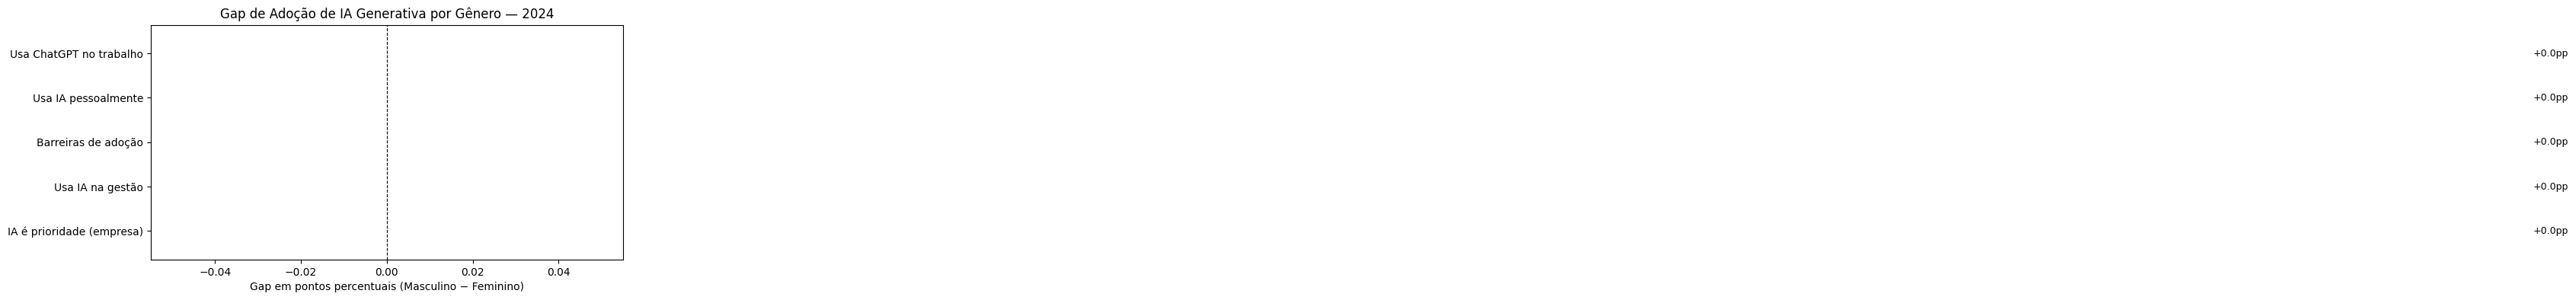

In [87]:
IA_LABELS = {
    'ia_prioridade_empresa':      'IA é prioridade (empresa)',
    'ia_tipos_uso_gestao':        'Usa IA na gestão',
    'ia_motivos_nao_usar':        'Barreiras de adoção',
    'ia_tipo_uso_pessoal':        'Usa IA pessoalmente',
    'ia_usa_chatgpt_no_trabalho': 'Usa ChatGPT no trabalho',
}

df24 = df[df['ano_pesquisa'] == '2024'].copy()
df24_ia = df24[df24[IA_FEATS_ALL].notna().any(axis=1)].copy()

for col in IA_FEATS_ALL:
    df24_ia[col + '_bin'] = (df24_ia[col] == 'Sim').where(df24_ia[col].notna()).astype(float)

feats_bin = [c + '_bin' for c in IA_FEATS_ALL]

tab_ia = (
    df24_ia.groupby('genero')[feats_bin]
    .mean().mul(100).round(1)
    .rename(columns={c + '_bin': IA_LABELS[c] for c in IA_FEATS_ALL})
)

gap = (tab_ia.loc['Masculino'] - tab_ia.loc['Feminino']).sort_values()
colors = ['#C2185B' if v < 0 else '#1976D2' for v in gap]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(gap.index, gap.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, v in zip(bars, gap.values):
    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        bar.get_y() + bar.get_height() / 2,
        f'{v:+.1f}pp', va='center',
        ha='left' if v >= 0 else 'right', fontsize=9,
    )
ax.set_xlabel('Gap em pontos percentuais (Masculino − Feminino)')
ax.set_title('Gap de Adoção de IA Generativa por Gênero — 2024')
plt.tight_layout()
plt.show()


In [84]:
# Subconjunto com ao menos uma feature de IA preenchida
df_ia = df[df[IA_FEATURES].notna().any(axis=1)].copy()

print(f"Respondentes com dados de IA: {len(df_ia):,} de {len(df):,} ({len(df_ia)/len(df)*100:.1f}%)")
print()
print(df_ia.groupby(['ano_pesquisa', 'genero']).size().unstack(fill_value=0))


Respondentes com dados de IA: 9,271 de 17,295 (53.6%)

genero        Feminino  Masculino
ano_pesquisa                     
2023              1093       3546
2024              1095       3537


In [85]:
# Binarização das features de IA (Sim = 1, demais = 0 ou NaN estrutural)
# ia_usa_chatgpt_no_trabalho: 'Sim' / 'Não'
# ia_prioridade_empresa: 'Sim' / 'Não' / 'Não sei'
# Para as outras (listas), considera preenchida = usa

for col in IA_FEATURES:
    col_bin = col + '_bin'
    if df_ia[col].dtype == object:
        # se contém 'Sim'/'Não' diretamente
        if df_ia[col].isin(['Sim', 'Não', 'Não sei']).any():
            df_ia[col_bin] = (df_ia[col] == 'Sim').astype(float)
            df_ia.loc[df_ia[col].isna(), col_bin] = float('nan')
        else:
            # listas/texto livre — considera preenchida como 'usa'
            df_ia[col_bin] = df_ia[col].notna().astype(float)
    else:
        df_ia[col_bin] = df_ia[col]

IA_FEATS_BIN = [c + '_bin' for c in IA_FEATURES]


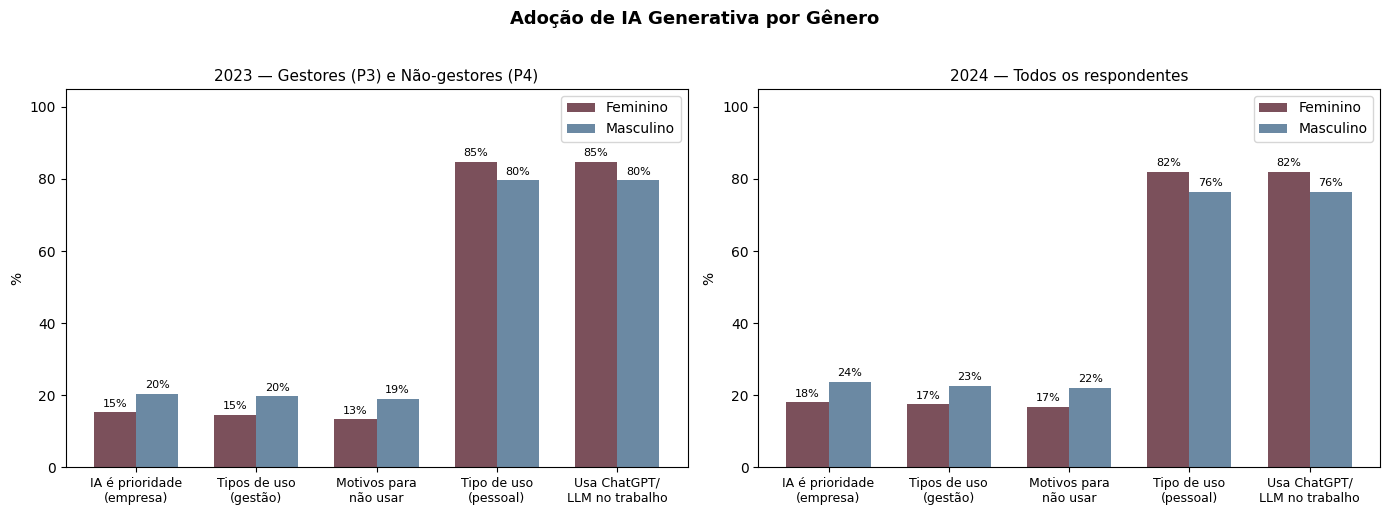

In [86]:
# Adoção de IA por gênero — estratificado por gestor (2023) e agregado (2024)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (label, subset) in zip(
    axes,
    [
        ('2023 — Gestores (P3) e Não-gestores (P4)', df_ia[df_ia['ano_pesquisa'] == '2023']),
        ('2024 — Todos os respondentes',             df_ia[df_ia['ano_pesquisa'] == '2024']),
    ]
):
    tab = (
        subset.groupby('genero')[IA_FEATS_BIN]
        .mean()
        .mul(100)
        .rename(columns={c + '_bin': IA_FEAT_LABELS[c] for c in IA_FEATURES})
        .T
    )

    if tab.empty:
        ax.set_title(label)
        ax.text(0.5, 0.5, 'Sem dados', ha='center', va='center', transform=ax.transAxes)
        continue

    x = range(len(tab))
    width = 0.35
    for j, genero in enumerate(['Feminino', 'Masculino']):
        if genero not in tab.columns:
            continue
        vals = tab[genero].fillna(0)
        bars = ax.bar(
            [xi + j * width for xi in x],
            vals,
            width=width,
            label=genero,
            color=CORES_GENERO[genero],
            alpha=0.85,
        )
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                        f'{v:.0f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks([xi + width / 2 for xi in x])
    ax.set_xticklabels(tab.index, fontsize=9)
    ax.set_ylabel('%')
    ax.set_title(label, fontsize=11)
    ax.legend()
    ax.set_ylim(0, 105)

plt.suptitle('Adoção de IA Generativa por Gênero', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/2.9_ia_adocao_genero.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.10 — Representatividade feminina por região

Análise complementar: a desigualdade de gênero tem padrão geográfico?  
Norte e Nordeste, com amostras menores, exigem cautela interpretativa  
(os `n` são exibidos explicitamente).


In [88]:
REGIOES = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']
df_reg = df[df['regiao'].isin(REGIOES)].copy()

fig = go.Figure()
for regiao in REGIOES:
    pcts, textos = [], []
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        n   = ct.sum()
        fem = ct.get('Feminino', 0)
        v   = round(fem / n * 100, 1) if n >= 10 else None
        pcts.append(v)
        textos.append(f'{v}%' if v else 'n<10')
    fig.add_trace(go.Scatter(
        x=ANOS, y=pcts, mode='lines+markers+text', name=regiao,
        line=dict(color=CORES_REGIAO[regiao], width=2.5), marker=dict(size=9),
        text=textos, textposition='top center',
    ))
fmt(fig, '% Feminino por Região (2021–2024)', height=420)
fig.update_yaxes(ticksuffix='%', range=[0, 45])
fig.show()


In [67]:
# Heatmap regional
matriz_reg = pd.DataFrame(index=REGIOES, columns=ANOS, dtype=float)
ns_reg     = pd.DataFrame(index=REGIOES, columns=ANOS, dtype=int)

for regiao in REGIOES:
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        n   = ct.sum()
        fem = ct.get('Feminino', 0)
        ns_reg.loc[regiao, ano]     = n
        matriz_reg.loc[regiao, ano] = round(fem / n * 100, 1) if n >= 10 else float('nan')

fig = go.Figure(go.Heatmap(
    z=matriz_reg.values.astype(float),
    x=ANOS, y=REGIOES,
    text=[[f"{v:.1f}%<br>n={ns_reg.loc[r,a]}"
           if not pd.isna(v) else f"n<10"
           for v, a in zip(row, ANOS)]
          for row, r in zip(matriz_reg.values.astype(object), REGIOES)],
    texttemplate='%{text}',
    colorscale='RdBu',
    zmid=25, zmin=0, zmax=50,
    colorbar=dict(title='% Feminino', ticksuffix='%'),
))
fig = fmt_layout(fig, 'Heatmap: % Feminino por Região e Ano (n exibido em cada célula)', height=360)
fig.show()


---
### Síntese dos achados exploratórios


| Dimensão | Achado central | Relevância para a dissertação |
|---|---|---|
| Representatividade temporal | — | * |
| Cargo  | — | *|
| Senioridade  | — | * |
| Salário | — | *|
| Escolaridade | — | * |
| Área de formação | — | * |
| Experiência | — | * |
| Modalidade | — | * |
| Adoção de IA | — | * |
| Regional | — | * |


---
## Seção 3 — Análise Estatística 

A análise estatística foi estruturada em quatro etapas principais: estatística descritiva, testes de hipótese, análise de correlação e modelagem estatística.

Para investigar associações entre gênero e variáveis estruturais do mercado de dados, aplicou-se o teste Qui-Quadrado de independência, acompanhado do coeficiente V de Cramér para mensuração do tamanho do efeito. As análises envolveram relações entre gênero e senioridade, liderança e faixa salarial. O teste Qui-Quadrado foi utilizado para verificar a existência de dependência estatística entre variáveis categóricas, enquanto o V de Cramér permitiu avaliar a intensidade dessas associações.

Adicionalmente, aplicou-se a correlação de Spearman para avaliar relações monotônicas entre variáveis ordinais, especialmente entre senioridade, experiência e faixa salarial. A escolha desse método deve-se à natureza ordinal das variáveis analisadas e à ausência de pressupostos paramétricos.

Na etapa de modelagem estatística, foi utilizada regressão logística simples para analisar tendências temporais da participação feminina ao longo do período estudado, considerando o modelo genero ~ ano_pesquisa. Em seguida, empregou-se regressão logística múltipla para identificar fatores estruturais associados ao gênero, incorporando variáveis como senioridade, faixa salarial, liderança, experiência e ano da pesquisa. Por fim, utilizou-se regressão logística ordinal para modelar probabilidades associadas à progressão em faixas salariais ordinais, respeitando a ordem natural das categorias de remuneração.

*Principais Hipóteses Investigadas*

- H1 - Existe associação entre gênero e senioridade.

- H2 - Existe associação entre gênero e liderança.

- H3 - Existe diferença salarial entre gêneros.

- H4 - Senioridade e experiência estão associadas à remuneração.

- H5 - A participação feminina apresenta tendência temporal significativa entre 2021 e 2024.

In [92]:
df['genero_bin']         = (df['genero'] == 'Feminino').astype(int)
df['faixa_salarial_num'] = (
    df['faixa_salarial']
    .map({v: i for i, v in enumerate(FAIXA_SALARIAL_ORDEM)})
    .astype(float)
)
df['nivel_num'] = (
    df['nivel']
    .map({v: i for i, v in enumerate(NIVEL_SENIORIDADE_ORDEM)})
    .astype(float)
)
df['ano_num']    = df['ano_pesquisa'].astype(int)
df['ano_centro'] = df['ano_num'] - 2021  # centrado em 2021

variaveis_chi2 = {
    'Nível de Senioridade': 'nivel',
    'Faixa Salarial':       'faixa_salarial',
    'Nível de Ensino':      'nivel_ensino',
    'Cargo':                'cargo',
    'Modalidade':           'modalidade',
    'Situação':             'situacao',
    'Área de Formação':     'area_formacao',
    'Região':               'regiao',
}

print(f'N total:     {len(df):,}')
print(f'N Feminino:  {(df["genero"]=="Feminino").sum():,} ({(df["genero"]=="Feminino").mean()*100:.1f}%)')
print(f'N Masculino: {(df["genero"]=="Masculino").sum():,} ({(df["genero"]=="Masculino").mean()*100:.1f}%)')

N total:     17,295
N Feminino:  4,055 (23.4%)
N Masculino: 13,240 (76.6%)


### 3.1 — Qui-quadrado + V de Cramér  (H1, H2 e associações gerais)

Pressuposto checado: reporta % células com expected < 5. Regra prática: se > 20% das células com expected < 5, resultado deve ser interpretado com cautela (indicado na coluna 'Pressuposto OK').

In [93]:
def cramers_v(ct: pd.DataFrame) -> float:
    """V de Cramér com correção de viés (Bergsma & Wicher, 2013)."""
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, c = ct.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (c - 1) / (n - 1))
    r_corr    = r - (r - 1) ** 2 / (n - 1)
    c_corr    = c - (c - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, c_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0


def teste_qui_quadrado(df: pd.DataFrame, col: str, label: str) -> dict:
    sub      = df.dropna(subset=[col, 'genero'])
    ct       = pd.crosstab(sub[col], sub['genero'])
    chi2, p, dof, expected = chi2_contingency(ct)
    v        = cramers_v(ct)
    pct_ok   = (expected >= 5).mean() * 100
    return {
        'Variável':            label,
        'N':                   len(sub),
        'χ²':                  round(chi2, 3),
        'gl':                  dof,
        'p-valor':             round(p, 6),
        'Significativo':       'Sim' if p < ALPHA else 'Não',
        'V de Cramér':         round(v, 4),
        'Magnitude':           ('Forte' if v >= .4 else 'Moderado' if v >= .2
                                 else 'Pequeno' if v >= .1 else 'Negligenciável'),
        '% células (exp≥5)':   f'{pct_ok:.0f}%',
        'Pressuposto OK':      'Sim' if pct_ok >= 80 else 'Atenção',
    }


tab_chi2 = pd.DataFrame(
    [teste_qui_quadrado(df, col, label) for label, col in variaveis_chi2.items()]
).set_index('Variável')

print('\n=== H1/H2 — Qui-quadrado + V de Cramér ===')
print(tab_chi2.to_string())



=== H1/H2 — Qui-quadrado + V de Cramér ===
                          N       χ²  gl   p-valor Significativo  V de Cramér       Magnitude % células (exp≥5) Pressuposto OK
Variável                                                                                                                      
Nível de Senioridade  12422   47.763   2  0.000000           Sim       0.0607  Negligenciável              100%            Sim
Faixa Salarial        15438  184.015  11  0.000000           Sim       0.1059         Pequeno              100%            Sim
Nível de Ensino       17269   89.471   5  0.000000           Sim       0.0699  Negligenciável              100%            Sim
Cargo                 12422  139.500   6  0.000000           Sim       0.1037         Pequeno              100%            Sim
Modalidade            15557   60.570   3  0.000000           Sim       0.0608  Negligenciável              100%            Sim
Situação              17295  118.078   9  0.000000           Sim   

### 3.2 — Mann-Whitney U  (H3: diferença salarial entre gêneros)

Decisão metodológica: two-sided — sem hipótese direcional a priori.
Effect size: rank-biserial correlation r = 2U/(n1*n2) - 1, ∈ [-1, 1].
  r > 0  → masculino tende a salários maiores
  r < 0  → feminino tende a salários maiores
Magnitude (Cohen): |r| < .1 negligenciável, .1–.3 pequeno,
                   .3–.5 médio, ≥ .5 grande.
Múltiplos subgrupos (por ano e região) são descritivos, não inferenciais
adicionais — sem correção de múltiplas comparações aplicada.

In [94]:
def rank_biserial(U: float, n1: int, n2: int) -> float:
    """Rank-biserial correlation para two-sided Mann-Whitney.

    r = 2U/(n1*n2) - 1
    Equivalente a: (proporção de pares onde grupo 1 > grupo 2) * 2 - 1.
    Intervalo: [-1, 1]; r=0 indica distribuições equivalentes.
    """
    return (2 * U) / (n1 * n2) - 1


def mann_whitney_salarial(df_sub: pd.DataFrame, label: str = 'Geral') -> dict | None:
    sub  = df_sub.dropna(subset=['faixa_salarial_num', 'genero'])
    masc = sub[sub['genero'] == 'Masculino']['faixa_salarial_num']
    fem  = sub[sub['genero'] == 'Feminino' ]['faixa_salarial_num']
    if len(masc) < 5 or len(fem) < 5:
        return None

    # two-sided: sem hipótese direcional a priori (H0: distribuições iguais)
    U, p = mannwhitneyu(masc, fem, alternative='two-sided')
    r    = rank_biserial(U, len(masc), len(fem))

    return {
        'Grupo':             label,
        'N Masc':            len(masc),
        'N Fem':             len(fem),
        'Mediana Masc':      FAIXA_SALARIAL_ORDEM[int(masc.median())],
        'Mediana Fem':       FAIXA_SALARIAL_ORDEM[int(fem.median())],
        'U':                 round(U),
        'p-valor':           round(p, 6),
        'Significativo':     'Sim' if p < ALPHA else 'Não',
        'r (rank-biserial)': round(r, 4),
        'Direção':           ('Masc > Fem' if r > 0 else 'Fem > Masc' if r < 0 else 'Neutro'),
        'Magnitude':         ('Grande' if abs(r) >= .5 else 'Médio'  if abs(r) >= .3
                               else 'Pequeno' if abs(r) >= .1 else 'Negligenciável'),
    }


res_mw = [mann_whitney_salarial(df, 'Brasil — Geral')]
for ano in ANOS:
    res_mw.append(mann_whitney_salarial(df[df['ano_pesquisa'] == ano], f'{ano}'))
for reg in sorted(df['regiao'].dropna().unique()):
    res_mw.append(mann_whitney_salarial(df[df['regiao'] == reg], f'Região: {reg}'))

tab_mw = pd.DataFrame([r for r in res_mw if r]).set_index('Grupo')
print('\n=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===')
print(tab_mw.to_string())



=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===
                      N Masc  N Fem Mediana Masc Mediana Fem         U   p-valor Significativo  r (rank-biserial)     Direção       Magnitude
Grupo                                                                                                                                        
Brasil — Geral         11900   3538     R$8k-12k     R$6k-8k  23712840  0.000000           Sim             0.1264  Masc > Fem         Pequeno
2021                    1892    430      R$6k-8k     R$6k-8k    454266  0.000131           Sim             0.1167  Masc > Fem         Pequeno
2022                    2749    876     R$8k-12k     R$6k-8k   1349824  0.000000           Sim             0.1211  Masc > Fem         Pequeno
2023                    3597   1099     R$8k-12k     R$6k-8k   2236891  0.000000           Sim             0.1317  Masc > Fem         Pequeno
2024                    3662   1133     R$8k-12k    R$8k-12k   2376175  0.000000        

### 3.3 — Correlação de Spearman  (H4: senioridade × remuneração)

Cobre H4 de forma mais direta que Kruskal-Wallis para variáveis ordinais:
mede a força e direção da associação monotônica entre nível e salário,
separando os grupos para avaliar se o gradiente difere por gênero.

In [99]:
def spearman_por_genero(df: pd.DataFrame, x: str, y: str,
                         label_x: str, label_y: str) -> pd.DataFrame:
    rows = []
    for genero in ['Masculino', 'Feminino', 'Geral']:
        sub = df if genero == 'Geral' else df[df['genero'] == genero]
        sub = sub.dropna(subset=[x, y])
        if len(sub) < 10:
            continue
        rho, p = spearmanr(sub[x], sub[y])
        rows.append({
            'Grupo':         genero,
            'N':             len(sub),
            f'ρ ({label_x} × {label_y})': round(rho, 4),
            'p-valor':       round(p, 6),
            'Significativo': 'Sim' if p < ALPHA else 'Não',
            'Magnitude':     ('Forte' if abs(rho) >= .5 else 'Moderada' if abs(rho) >= .3
                               else 'Fraca' if abs(rho) >= .1 else 'Negligenciável'),
        })
    return pd.DataFrame(rows).set_index('Grupo')


# H4a: nível de senioridade × faixa salarial
tab_sp_nivel_sal = spearman_por_genero(
    df, 'nivel_num', 'faixa_salarial_num',
    'Senioridade', 'Salário'
)

# H4b: experiência × faixa salarial (complementar, se a coluna existir)
if 'tempo_area_dados' in df.columns:
    df['experiencia_num'] = pd.Categorical(
        df['tempo_area_dados'],
        categories=[
            'Menos de 1 ano', 'de 1 a 2 anos', 'de 3 a 4 anos',
            'de 4 a 5 anos', 'de 5 a 6 anos', 'de 7 a 10 anos',
            'Mais de 10 anos',
        ],
        ordered=True
    ).codes.astype(float).replace(-1, np.nan)

    tab_sp_exp_sal = spearman_por_genero(
        df, 'experiencia_num', 'faixa_salarial_num',
        'Experiência', 'Salário'
    )
else:
    tab_sp_exp_sal = pd.DataFrame()

print('\n=== H4 — Spearman: Senioridade × Salário ===')
print(tab_sp_nivel_sal.to_string())

if not tab_sp_exp_sal.empty:
    print('\n=== H4 — Spearman: Experiência × Salário ===')
    print(tab_sp_exp_sal.to_string())

AttributeError: 'numpy.ndarray' object has no attribute 'replace'

### 3.4 — Regressão Logística Simples — Tendência Temporal  (H5)

Modelo: P(Feminino) ~ ano_centro
ano_centro = ano - 2021 (centrado para facilitar interpretação do intercepto)
Reporta OR, IC 95% e pseudo-R² de McFadden.

In [96]:
def regressao_temporal(df_sub: pd.DataFrame, label: str = 'Brasil') -> dict | None:
    sub = df_sub.dropna(subset=['genero_bin', 'ano_centro'])
    if len(sub) < 50:
        return None
    X   = sm.add_constant(sub['ano_centro'])
    mod = sm.Logit(sub['genero_bin'], X).fit(disp=False)

    coef = mod.params['ano_centro']
    p    = mod.pvalues['ano_centro']
    OR   = np.exp(coef)
    ci   = np.exp(mod.conf_int().loc['ano_centro'])
    llf  = mod.llf
    llnull = mod.llnull
    mcfadden_r2 = 1 - llf / llnull  # pseudo-R² de McFadden

    return {
        'Grupo':            label,
        'N':                len(sub),
        'β (log-odds/ano)': round(coef, 4),
        'OR':               round(OR, 4),
        'IC 95% OR':        f'[{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]',
        'p-valor':          round(p, 6),
        'Significativo':    'Sim' if p < ALPHA else 'Não',
        'McFadden R²':      round(mcfadden_r2, 4),
        'Tendência':        ('Crescente'  if coef > 0 and p < ALPHA
                              else 'Decrescente' if coef < 0 and p < ALPHA
                              else 'Estável'),
    }


res_temp = [regressao_temporal(df, 'Brasil — Geral')]
for reg in sorted(df['regiao'].dropna().unique()):
    res_temp.append(regressao_temporal(df[df['regiao'] == reg], f'Região: {reg}'))

tab_temp = pd.DataFrame([r for r in res_temp if r]).set_index('Grupo')
print('\n=== H5 — Tendência Temporal da Representatividade Feminina ===')
print(tab_temp.to_string())


=== H5 — Tendência Temporal da Representatividade Feminina ===
                          N  β (log-odds/ano)      OR       IC 95% OR   p-valor Significativo  McFadden R²  Tendência
Grupo                                                                                                                
Brasil — Geral        17295            0.0585  1.0603  [1.025, 1.097]  0.000711           Sim       0.0006  Crescente
Região: Centro-Oeste   1071            0.1135  1.1202  [0.971, 1.292]  0.119501           Não       0.0023    Estável
Região: Nordeste       1971            0.0407  1.0415  [0.940, 1.155]  0.439353           Não       0.0003    Estável
Região: Norte           256           -0.0507  0.9505  [0.691, 1.308]  0.755645           Não       0.0004    Estável
Região: Sudeste       10542            0.0557  1.0573  [1.013, 1.103]  0.010410           Sim       0.0006  Crescente
Região: Sul            3044            0.0722  1.0748  [0.989, 1.169]  0.090758           Não       0.0009    

In [97]:
with pd.ExcelWriter('resultados_estatisticos.xlsx') as writer:
    tab_chi2.to_excel(writer,          sheet_name='Chi2 e Cramer V')
    tab_mw.to_excel(writer,            sheet_name='Mann-Whitney Salarial')
    tab_sp_nivel_sal.to_excel(writer,  sheet_name='Spearman Nivel x Salario')
    if not tab_sp_exp_sal.empty:
        tab_sp_exp_sal.to_excel(writer, sheet_name='Spearman Exp x Salario')
    tab_temp.to_excel(writer,          sheet_name='Tendencia Temporal')

print('\n resultados_estatisticos.xlsx salvo')

NameError: name 'tab_sp_nivel_sal' is not defined

---
## Seção 4 — Modelagem Preditiva (Machine Learning)

### Estratégia

| Aspecto | Decisão |
|---|---|
| Treino | 2021–2023 (**inclui features de IA de 2023**) |
| Teste  | 2024 (**inclui features de IA de 2024**) |
| Targets | Faixa Salarial · Senioridade · Gestor/a |
| Modelos | Logistic Regression · Random Forest · XGBoost |
| Seleção | Melhor F1-macro em CV 5-fold estratificado |

> **Modelo A:** treino 2021–2023 sem IA / teste 2024 sem IA — baseline  
> **Modelo B:** treino 2021–2023 **com IA de 2023** / teste 2024 **com IA de 2024** — comparação honesta
>
> A comparação A vs B responde: **"IA generativa é preditor relevante de salário/senioridade?"**

In [ ]:
BASE_FEATURES = [
    'nivel_ensino', 'area_formacao', 'cargo',
    'tempo_area_dados', 'tempo_area_ti', 'modalidade',
    'setor', 'regiao', 'situacao',
]
TARGETS = {
    'faixa_salarial': 'multiclass',
    'nivel':          'multiclass',
    'gestor':         'binario',
}
TARGET_LABELS = {
    'faixa_salarial': 'Faixa Salarial',
    'nivel':          'Senioridade',
    'gestor':         'Gestor/a',
}

def encode_ordinal(series, ordem):
    cat   = pd.Categorical(series, categories=ordem, ordered=True)
    codes = cat.codes.astype(float)
    codes[codes == -1] = np.nan
    return codes

def prepare_xy(df: pd.DataFrame, target: str, extra_features: list = None):
    feats = BASE_FEATURES.copy()
    if extra_features:
        feats += [f for f in extra_features if f in df.columns]
    sub = df[feats + [target, 'ano_pesquisa', 'genero']].copy()
    sub['nivel_ensino'] = encode_ordinal(sub['nivel_ensino'], NIVEL_ENSINO_ORDEM)
    if target == 'faixa_salarial':
        sub['y'] = encode_ordinal(sub['faixa_salarial'], FAIXA_SALARIAL_ORDEM)
    elif target == 'nivel':
        sub['y'] = encode_ordinal(sub['nivel'], NIVEL_SENIORIDADE_ORDEM)
    elif target == 'gestor':
        sub['y'] = (sub['gestor'] == 1.0).astype(float)
    sub = sub.dropna(subset=['y'])
    sub['y'] = sub['y'].astype(int)
    return sub[feats].copy(), sub['y'], sub[['genero', 'ano_pesquisa']].copy()

def build_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    transformers = []
    if num_cols:
        transformers.append(('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler()),
        ]), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_cols))
    return ColumnTransformer(transformers, remainder='drop')

def get_models(task_type):
    if task_type == 'binario':
        return {
            'Regressão Logística': LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'),
            'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
            'XGBoost':             XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', scale_pos_weight=5, verbosity=0),
        }
    return {
        'Regressão Logística': LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'),
        'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
        'XGBoost':             XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='mlogloss', verbosity=0),
    }

def run_cv(X, y, models, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    results = []
    for name, model in models.items():
        pipe   = Pipeline([('pre', build_preprocessor(X)), ('clf', model)])
        scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        results.append({'Modelo': name, 'F1_macro_mean': scores.mean(), 'F1_macro_std': scores.std()})
        print(f'    {name:25s}: {scores.mean():.3f} ± {scores.std():.3f}')
    return pd.DataFrame(results)

# Quando o target é gestor, remove 'nivel' das features.
# Motivo: nivel='Gestor' e gestor=1 são altamente correlacionados —
# manter nivel tornaria o target trivialmente predizível.
if target == 'gestor' and 'nivel' in feats:
    feats = [f for f in feats if f != 'nivel']
    
def treinar_avaliar(target, task_type, df_train, df_test, extra_features=None, label_extra=''):
    tag = f'{TARGET_LABELS[target]}{" " + label_extra if label_extra else ""}'
    print(f'\n{"="*60}\n  {tag}\n{"="*60}')
    X_train, y_train, _         = prepare_xy(df_train, target, extra_features)
    X_test,  y_test,  meta_test = prepare_xy(df_test,  target, extra_features)
    print(f'  Treino: {len(X_train):,} | Teste: {len(X_test):,} | Classes: {sorted(y_train.unique())}')
    print(f'\n  [CV 5-fold — F1-macro]')
    models    = get_models(task_type)
    cv_df     = run_cv(X_train, y_train, models)
    best_name = cv_df.loc[cv_df['F1_macro_mean'].idxmax(), 'Modelo']
    print(f'\n  Melhor modelo: {best_name}')
    pipe = Pipeline([('pre', build_preprocessor(X_train)), ('clf', models[best_name])])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f'\n  [Classificação — Teste]')
    print(classification_report(y_test, y_pred, zero_division=0))
    gender_rows = []
    for g in ['Masculino', 'Feminino']:
        mask = meta_test['genero'] == g
        if mask.sum() == 0: continue
        gender_rows.append({
            'Gênero': g, 'N': int(mask.sum()),
            'Acurácia': round(accuracy_score(y_test[mask], y_pred[mask]), 4),
            'F1_macro': round(f1_score(y_test[mask], y_pred[mask], average='macro', zero_division=0), 4),
        })
    print(f'\n  [Fairness por Gênero]')
    print(pd.DataFrame(gender_rows).to_string(index=False))
    return {
        'target': target, 'label': tag, 'best_name': best_name, 'pipe': pipe,
        'cv_df': cv_df, 'X_train': X_train, 'X_test': X_test,
        'y_test': y_test, 'y_pred': y_pred, 'gender_rows': gender_rows, 'meta_test': meta_test,
    }



NameError: name 'target' is not defined

In [ ]:
df_train = pd.read_parquet('data/df_train.parquet')
df_test  = pd.read_parquet('data/df_test.parquet')

print(f'df_train: {len(df_train):,} linhas — anos {sorted(df_train["ano_pesquisa"].unique())}')
print(f'df_test:  {len(df_test):,}  linhas — anos {sorted(df_test["ano_pesquisa"].unique())}')

# Features de IA disponíveis e preenchidas em cada split
ia_treino = [c for c in IA_FEATS_ALL if c in df_train.columns and df_train[c].notna().sum() > 0]
ia_teste  = [c for c in IA_FEATS_ALL if c in df_test.columns  and df_test[c].notna().sum()  > 0]
print(f'\nIA no treino: {len(ia_treino)}/{len(IA_FEATS_ALL)} features ({df_train[ia_treino].notna().any(axis=1).mean()*100:.1f}% das linhas preenchidas)')
print(f'IA no teste:  {len(ia_teste)}/{len(IA_FEATS_ALL)} features ({df_test[ia_teste].notna().any(axis=1).mean()*100:.1f}% das linhas preenchidas)')

df_train: 12,117 linhas — anos ['2021', '2022', '2023']
df_test:  5,178  linhas — anos ['2024']

IA no treino: 0/5 features (0.0% das linhas preenchidas)
IA no teste:  0/5 features (0.0% das linhas preenchidas)


In [ ]:
# Modelo A — Treino 2021–2023 / Teste 2024 — SEM features de IA (baseline)
results_A = {}
for target, task_type in TARGETS.items():
    results_A[target] = treinar_avaliar(
        target, task_type, df_train, df_test,
        extra_features=None, label_extra='[A — sem IA]',
    )


  Faixa Salarial [A — sem IA]
  Treino: 10,643 | Teste: 4,795 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

  [CV 5-fold — F1-macro]
    Regressão Logística      : 0.262 ± 0.007
    Random Forest            : 0.265 ± 0.011
    XGBoost                  : 0.262 ± 0.010

  Melhor modelo: Random Forest

  [Classificação — Teste]
              precision    recall  f1-score   support

           0       0.51      0.68      0.58       151
           1       0.26      0.23      0.25       235
           2       0.19      0.16      0.18       268
           3       0.31      0.35      0.33       592
           4       0.23      0.18      0.20       649
           5       0.37      0.50      0.42      1070
           6       0.30      0.34      0.32       714
           7       0.27      0.16      0.20       453
           8       0.18      0.13      0.15       246
      

In [ ]:
# Modelo B — Treino 2021–2023 (IA de 2023) / Teste 2024 (IA de 2024)
# Usa apenas as features de IA que têm dados tanto no treino quanto no teste
ia_comum = [c for c in IA_FEATS_ALL if c in ia_treino and c in ia_teste]
print(f'Features de IA comuns (treino ∩ teste): {len(ia_comum)}')
print()

results_B = {}
for target, task_type in TARGETS.items():
    results_B[target] = treinar_avaliar(
        target, task_type, df_train, df_test,
        extra_features=ia_comum, label_extra='[B — base + IA]',
    )

Features de IA comuns (treino ∩ teste): 0


  Faixa Salarial [B — base + IA]
  Treino: 10,643 | Teste: 4,795 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

  [CV 5-fold — F1-macro]
    Regressão Logística      : 0.262 ± 0.007
    Random Forest            : 0.265 ± 0.011
    XGBoost                  : 0.262 ± 0.010

  Melhor modelo: Random Forest

  [Classificação — Teste]
              precision    recall  f1-score   support

           0       0.51      0.68      0.58       151
           1       0.26      0.23      0.25       235
           2       0.19      0.16      0.18       268
           3       0.31      0.35      0.33       592
           4       0.23      0.18      0.20       649
           5       0.37      0.50      0.42      1070
           6       0.30      0.34      0.32       714
           7       0.27      0.16      0.20       453
           8  

---
## Seção 5 — Explicabilidade com SHAP

In [ ]:
def compute_shap(pipe, X, model_name, max_samples=600):
    pre = pipe.named_steps['pre']; clf = pipe.named_steps['clf']
    X_t = pre.transform(X)
    try:
        feat_names = np.array(pre.get_feature_names_out())
    except Exception:
        feat_names = np.array([f'f{i}' for i in range(X_t.shape[1])])
    n   = min(max_samples, X_t.shape[0])
    idx = np.random.RandomState(SEED).choice(X_t.shape[0], n, replace=False)
    X_s = X_t[idx]
    if 'XGBoost' in model_name or 'Random Forest' in model_name:
        sv = shap.TreeExplainer(clf).shap_values(X_s)
    else:
        sv = shap.LinearExplainer(clf, X_s, feature_dependence='independent').shap_values(X_s)
    mean_abs = np.mean([np.abs(s) for s in sv], axis=0) if isinstance(sv, list) else np.abs(sv)
    return mean_abs.mean(axis=0), feat_names

def plot_shap_bar(mean_shap, feat_names, top_n=15, title='SHAP', fname='shap.png', highlight_ia=False):
    top_idx = np.argsort(mean_shap)[::-1][:top_n]
    names   = feat_names[top_idx]; vals = mean_shap[top_idx]
    clean   = lambda n: n.replace('cat__', '').replace('num__', '')
    names_c = [clean(n) for n in names]
    colors  = ['#F4A43B' if 'ia_' in n else '#4C8FBF' for n in names_c] if highlight_ia else ['#4C8FBF']*len(names_c)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(names_c[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(title, fontweight='bold', loc='left')
    if highlight_ia:
        ax.legend(handles=[
            mpatches.Patch(color='#F4A43B', label='Feature de IA generativa'),
            mpatches.Patch(color='#4C8FBF', label='Feature base'),
        ], loc='lower right', frameon=False)
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  💾 figures/{fname}')

print('✅ Funções SHAP definidas')

✅ Funções SHAP definidas


In [ ]:
shap_cache = {}
for target in TARGETS:
    safe = target.replace(' ', '_')
    for key, results, hl in [('A', results_A, False), ('B', results_B, True)]:
        try:
            r = results[target]
            ms, fn = compute_shap(r['pipe'], r['X_test'], r['best_name'])
            shap_cache[f'{key}_{target}'] = (ms, fn)
            plot_shap_bar(ms, fn,
                title=f'SHAP — {TARGET_LABELS[target]} · Modelo {key} ({r["best_name"]})',
                fname=f'shap_{key}_{safe}.png', highlight_ia=hl)
        except Exception as e:
            print(f'⚠️ SHAP Modelo {key} / {target}: {e}')

In [ ]:
def plot_shap_comparacao(target, top_n=12):
    """Compara lado a lado o SHAP do Modelo A (sem IA) e B (com IA)."""
    key_a, key_b = f'A_{target}', f'B_{target}'
    if key_a not in shap_cache or key_b not in shap_cache:
        print(f'⚠️ SHAP não disponível para {target}'); return
    clean = lambda n: n.replace('cat__', '').replace('num__', '')
    def top(ms, fn, n):
        idx = np.argsort(ms)[::-1][:n]
        return [clean(fn[i]) for i in idx], ms[idx]
    ms_a, fn_a = shap_cache[key_a]; ms_b, fn_b = shap_cache[key_b]
    names_a, vals_a = top(ms_a, fn_a, top_n)
    names_b, vals_b = top(ms_b, fn_b, top_n)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, names, vals, subtitle, hl in [
        (axes[0], names_a, vals_a, 'Modelo A (sem IA)', False),
        (axes[1], names_b, vals_b, 'Modelo B (com IA de 2023 e 2024)', True),
    ]:
        colors = ['#F4A43B' if 'ia_' in n else '#4C8FBF' for n in names] if hl else ['#4C8FBF']*len(names)
        ax.barh(names[::-1], vals[::-1], color=colors[::-1])
        ax.set_xlabel('Mean |SHAP value|'); ax.set_title(subtitle, fontweight='bold')
    fig.suptitle(f'SHAP Comparativo — {TARGET_LABELS[target]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'figures/shap_comp_{target}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  💾 {fname}')

for target in TARGETS:
    plot_shap_comparacao(target)